# Pharmaceutical Market Intelligence
# Notebook 02 — Advanced Pharmaceutical Forecasting

## Objective

Build a forecasting engine for the pharmaceutical market using:

- Historical market data
- Brand-level sales
- Molecule / Active Ingredient level data
- Statistical forecasting
- Machine Learning forecasting
- Backtesting
- Model comparison
- Forecast confidence
- Forecast risk signals

### Final Outputs

1. Market Forecast
2. Molecule Forecast
3. Brand Forecast
4. Model Performance Comparison
5. Forecast Growth
6. Forecast Risk
7. Strategic Forecast Portfolio

In [4]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
import numpy as np

pd.set_option ("display.max_columns" ,None)

In [3]:
df=  pd.read_excel ("IMS (2021-2025).xlsx")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909922 entries, 0 to 909921
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Sector         909922 non-null  object        
 1   ATC4           909922 non-null  object        
 2   Corporation    909922 non-null  object        
 3   Product        909922 non-null  object        
 4   Pack           909922 non-null  object        
 5   Launch Date    909922 non-null  object        
 6   Strength       909922 non-null  object        
 7   Retail Price   909922 non-null  float64       
 8   NFC3           909922 non-null  object        
 9   Period         909922 non-null  datetime64[ns]
 10  Calendar Year  909922 non-null  int64         
 11  Units          909922 non-null  float64       
 12  LC Value       909922 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(8)
memory usage: 90.2+ MB


In [6]:
df.columns

Index(['Sector', 'ATC4', 'Corporation', 'Product', 'Pack', 'Launch Date',
       'Strength', 'Retail Price', 'NFC3', 'Period', 'Calendar Year', 'Units',
       'LC Value'],
      dtype='object')

In [7]:
df.shape

(909922, 13)

In [8]:
df.describe (include ="all")

,Sector,ATC4,Corporation,Product,Pack,Launch Date,Strength,Retail Price,NFC3,Period,Calendar Year,Units,LC Value
count,909922,909922,909922,909922,909922,909922,909922,909922.000000,909922,909922,909922.000000,9.099220e+05,9.099220e+05
unique,2,513,1396,9958,8835,469,459,NaN,209,NaN,NaN,NaN,NaN
top,PHARMACIES,M01A1 ANTIRHEUMATICS NON-S PLN,PHARCO*,HERO BABY FOOD,SYRUP 120ML,No Launch Date,000,NaN,ABC ORAL S ORD FILM-COATED TABS,NaN,NaN,NaN,NaN
freq,540117,24986,34534,2349,10649,9335,280100,NaN,185866,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,652.735979,NaN,2023-06-30 02:11:28.901246208,2023.034219,1.682607e+04,9.702826e+05
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010000,NaN,2021-01-01 00:00:00,2021.000000,3.000000e-02,1.000000e-02
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.000000,NaN,2022-04-01 00:00:00,2022.000000,1.020000e+02,6.800000e+03
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78.000000,NaN,2023-07-01 00:00:00,2023.000000,1.047000e+03,6.936600e+04
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,160.000000,NaN,2024-10-01 00:00:00,2024.000000,7.462000e+03,4.821098e+05
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,375504.000000,NaN,2025-12-01 00:00:00,2025.000000,6.080044e+06,2.679121e+08


In [9]:
df.isnull().sum()

Sector           0
ATC4             0
Corporation      0
Product          0
Pack             0
Launch Date      0
Strength         0
Retail Price     0
NFC3             0
Period           0
Calendar Year    0
Units            0
LC Value         0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

Sector                2
ATC4                513
Corporation        1396
Product            9958
Pack               8835
Launch Date         469
Strength            459
Retail Price       1999
NFC3                209
Period               60
Calendar Year         5
Units            142846
LC Value         408017
dtype: int64

In [12]:
df = df.rename(columns={
    "Sector": "Distribution Channel",
    "ATC4": "Therapeutic Class",
    "Corporation": "Manufacturer",
    "Product": "Brand Name",
    "Pack": "Pack Size",
    "Launch Date": "Product Launch",
    "Strength": "Drug Strength",
    "Retail Price": "Selling Price",
    "NFC3": "Market Category",
    "Period": "Month",
    "Calendar Year": "Year",
    "Units": "Sales Units",
    "LC Value": "Sales Value"
})

Data Dictionary
The dataset contains monthly pharmaceutical sales data in Egypt (2021–2025).

Column	Description
Distribution Channel	Sales channel (e.g., Pharmacies)
Therapeutic Class	ATC therapeutic classification
Manufacturer	Pharmaceutical company
Brand Name	Drug brand
Pack Size	Product package size
Product Launch	Product launch date
Drug Strength	Active ingredient strength
Selling Price	Retail selling price
Market Category	Market category
Month	Monthly reporting period
Year	Calendar year
Sales Units	Number of units sold
Sales Value	Sales revenue in local currency


In [13]:
df.describe()

,Selling Price,Month,Year,Sales Units,Sales Value
count,909922.000000,909922,909922.000000,9.099220e+05,9.099220e+05
mean,652.735979,2023-06-30 02:11:28.901246208,2023.034219,1.682607e+04,9.702826e+05
min,0.010000,2021-01-01 00:00:00,2021.000000,3.000000e-02,1.000000e-02
25%,40.000000,2022-04-01 00:00:00,2022.000000,1.020000e+02,6.800000e+03
50%,78.000000,2023-07-01 00:00:00,2023.000000,1.047000e+03,6.936600e+04
75%,160.000000,2024-10-01 00:00:00,2024.000000,7.462000e+03,4.821098e+05
max,375504.000000,2025-12-01 00:00:00,2025.000000,6.080044e+06,2.679121e+08
std,6548.015532,NaN,1.419715,6.995553e+04,3.734752e+06


In [14]:
# ============================================================
# 2. DATA VALIDATION
# ============================================================

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (909922, 13)

Columns:
['Distribution Channel', 'Therapeutic Class', 'Manufacturer', 'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength', 'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units', 'Sales Value']

Data Types:


Distribution Channel            object
Therapeutic Class               object
Manufacturer                    object
Brand Name                      object
Pack Size                       object
Product Launch                  object
Drug Strength                   object
Selling Price                  float64
Market Category                 object
Month                   datetime64[ns]
Year                             int64
Sales Units                    float64
Sales Value                    float64
dtype: object


First 5 Rows:


,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value
0,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-01-01,2021,124790.0,1871850.0
1,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-02-01,2021,112962.0,1694430.0
2,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-03-01,2021,108014.0,1620210.0
3,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-04-01,2021,88090.0,1321350.0
4,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-05-01,2021,76111.0,1141665.0


All required forecasting columns are available.
Date column: Month
Invalid dates: 0
Date Range: 2021-01-01 00:00:00 → 2025-12-01 00:00:00


,Month,Year,Month_Number,Quarter,Year_Month
0,2021-01-01,2021,1,1,2021-01-01
1,2021-02-01,2021,2,1,2021-02-01
2,2021-03-01,2021,3,1,2021-03-01
3,2021-04-01,2021,4,2,2021-04-01
4,2021-05-01,2021,5,2,2021-05-01


,Month,Sales_Value
0,2021-01-01,7.838593e+09
1,2021-02-01,7.254915e+09
2,2021-03-01,8.702145e+09
3,2021-04-01,7.727591e+09
4,2021-05-01,8.863685e+09


,Month,Sales_Value
55,2025-08-01,2.382179e+10
56,2025-09-01,2.682275e+10
57,2025-10-01,2.603899e+10
58,2025-11-01,2.663930e+10
59,2025-12-01,2.693493e+10


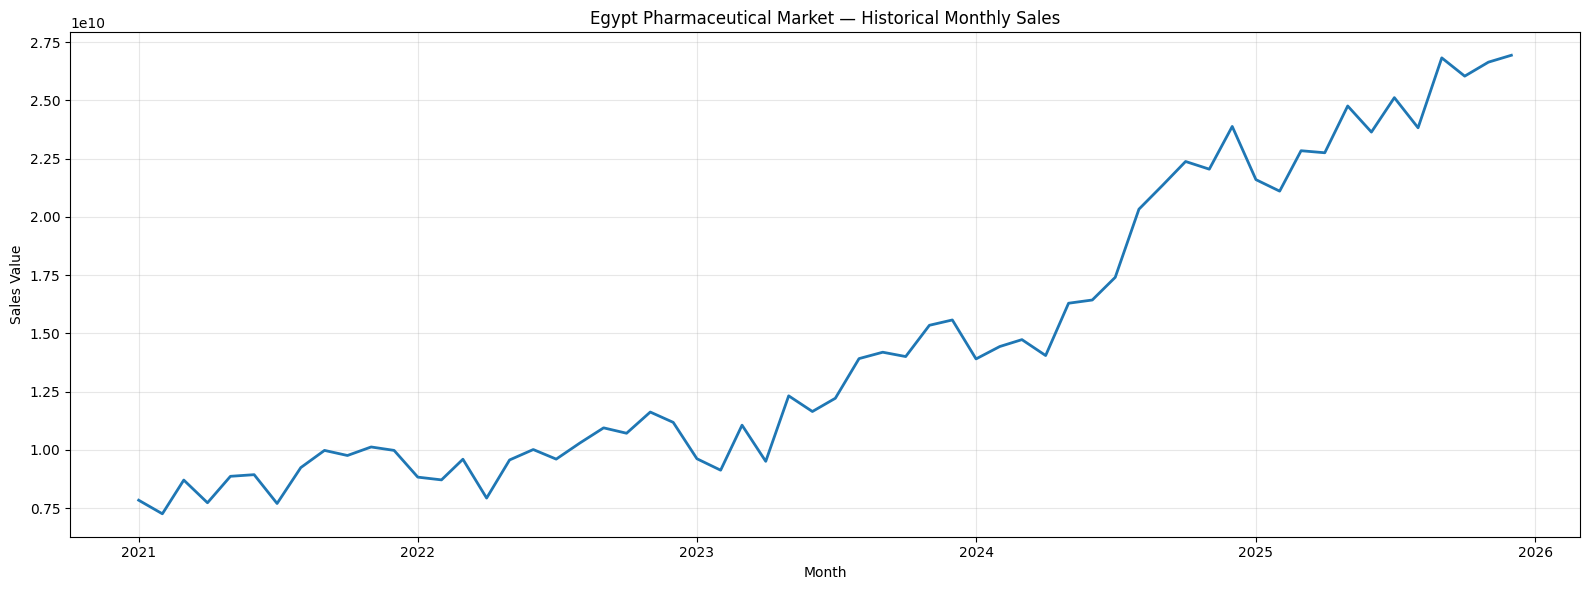

In [16]:
# ============================================================
# 3. REQUIRED COLUMNS
# ============================================================

required_columns = [
    "Brand Name",
    "Sales Value",
    "Month"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:")
    print(missing_columns)
else:
    print("All required forecasting columns are available.")


# ============================================================
# 4. DATE PREPARATION
# ============================================================

# The new dataset uses "Month" as the monthly reporting period.
date_column = "Month"

if date_column not in df.columns:
    print("No monthly date column detected.")
else:
    print("Date column:", date_column)

    # Convert Month to datetime
    df[date_column] = pd.to_datetime(
        df[date_column],
        errors="coerce"
    )

    # Check invalid dates
    invalid_dates = df[date_column].isna().sum()

    print("Invalid dates:", invalid_dates)

    print(
        "Date Range:",
        df[date_column].min(),
        "→",
        df[date_column].max()
    )


# ============================================================
# 5. TIME FEATURES
# ============================================================

if date_column in df.columns:

    # Calendar year
    df["Year"] = df[date_column].dt.year

    # Calendar month number
    df["Month_Number"] = df[date_column].dt.month

    # Quarter
    df["Quarter"] = df[date_column].dt.quarter

    # Standard monthly timestamp
    df["Year_Month"] = (
        df[date_column]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    display(
        df[
            [
                date_column,
                "Year",
                "Month_Number",
                "Quarter",
                "Year_Month"
            ]
        ].head()
    )


# ============================================================
# 6. MONTHLY MARKET SALES
# ============================================================

monthly_market = (
    df.groupby("Year_Month")["Sales Value"]
    .sum()
    .reset_index()
)

monthly_market.columns = [
    "Month",
    "Sales_Value"
]

monthly_market = (
    monthly_market
    .sort_values("Month")
    .reset_index(drop=True)
)

display(monthly_market.head())
display(monthly_market.tail())


# ============================================================
# 7. MARKET TREND
# ============================================================

plt.figure(figsize=(16, 6))

plt.plot(
    monthly_market["Month"],
    monthly_market["Sales_Value"],
    linewidth=2
)

plt.title(
    "Egypt Pharmaceutical Market — Historical Monthly Sales"
)

plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

,Month,Sales_Value,MoM_Growth,YoY_Growth
36,2024-01-01,1.390228e+10,-10.733250,44.546639
37,2024-02-01,1.443395e+10,3.824352,58.161882
38,2024-03-01,1.473001e+10,2.051080,33.205621
39,2024-04-01,1.404791e+10,-4.630682,47.767042
40,2024-05-01,1.629234e+10,15.976999,32.271492
41,2024-06-01,1.643094e+10,0.850692,41.096530
42,2024-07-01,1.740435e+10,5.924265,42.499771
43,2024-08-01,2.032865e+10,16.802141,46.088439
44,2024-09-01,2.135632e+10,5.055254,50.506992
45,2024-10-01,2.237542e+10,4.771909,59.781460


,Year,Sales_Value,YoY_Growth
0,2021,1.060877e+11,NaN
1,2022,1.189950e+11,12.166627
2,2023,1.485131e+11,24.806131
3,2024,2.172278e+11,46.268448
4,2025,2.920578e+11,34.447708


Historical Market CAGR: 28.81%
Training observations: 48
Testing observations: 12

Training: 2021-01-01 00:00:00 → 2024-12-01 00:00:00
Testing: 2025-01-01 00:00:00 → 2025-12-01 00:00:00
NAIVE MODEL
----------------
MAE  : 1,713,570,463.99
RMSE : 1,998,353,969.74
MAPE : 7.00%
SEASONAL NAIVE
----------------
MAE  : 6,235,833,473.16
RMSE : 6,545,804,310.96
MAPE : 26.17%
EXPONENTIAL SMOOTHING
----------------------
MAE  : 3,470,378,139.83
RMSE : 3,967,698,160.73
MAPE : 13.88%


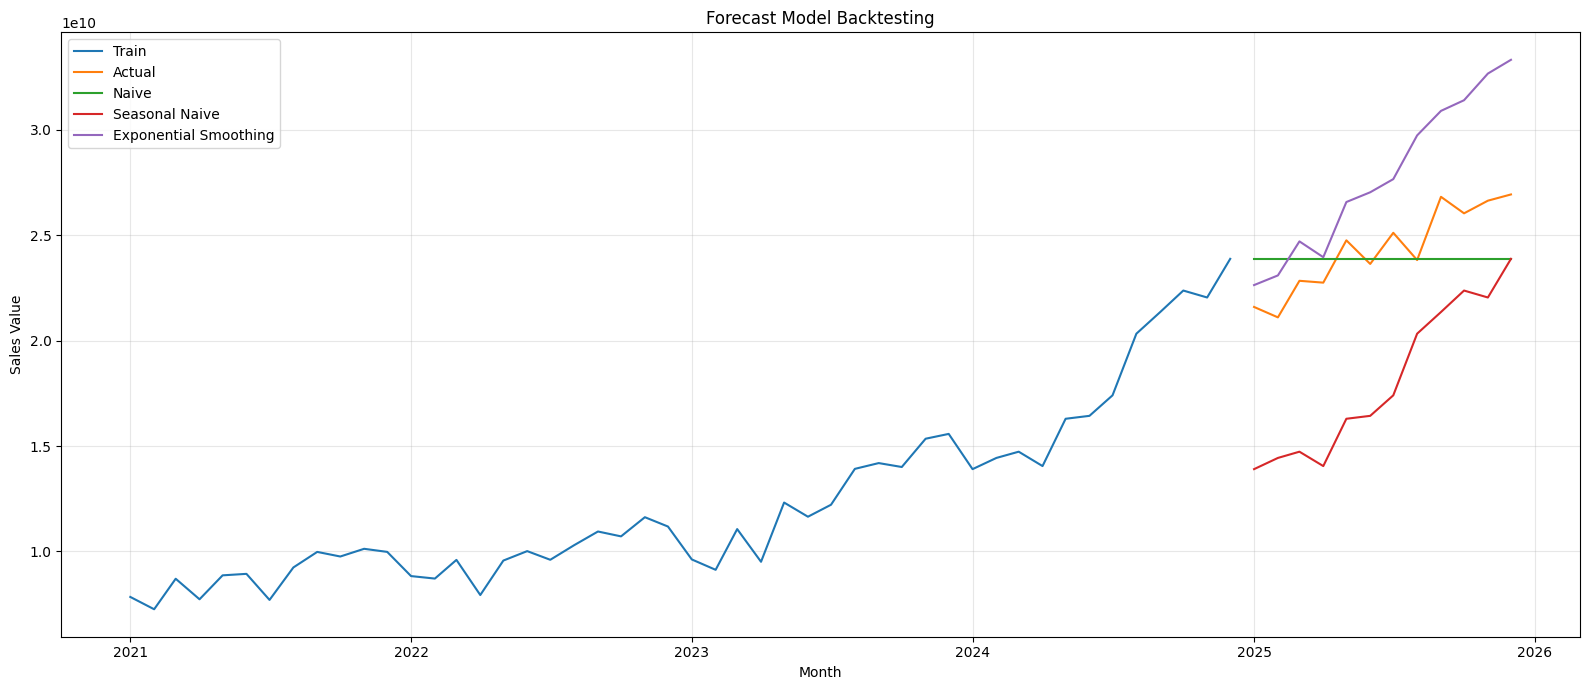

,Model,MAE,RMSE,MAPE
0,Naive,1.713570e+09,1.998354e+09,6.996617
1,Exponential Smoothing,3.470378e+09,3.967698e+09,13.881775
2,Seasonal Naive,6.235833e+09,6.545804e+09,26.172498


LINEAR REGRESSION
------------------
MAE  : 4,468,109,965.85
RMSE : 4,526,923,187.78
MAPE : 18.39%
R²   : -4.4169
RANDOM FOREST
----------------
MAE  : 3,258,955,941.05
RMSE : 3,709,092,596.15
MAPE : 12.88%
R²   : -2.6365
GRADIENT BOOSTING
------------------
MAE  : 2,243,499,803.00
RMSE : 2,592,386,470.03
MAPE : 8.87%
R²   : -0.7764


,Model,MAE,RMSE,MAPE,R2
0,Naive,1.713570e+09,1.998354e+09,6.996617,NaN
1,Gradient Boosting,2.243500e+09,2.592386e+09,8.867292,-0.776423
2,Random Forest,3.258956e+09,3.709093e+09,12.882883,-2.636488
3,Exponential Smoothing,3.470378e+09,3.967698e+09,13.881775,NaN
4,Linear Regression,4.468110e+09,4.526923e+09,18.388752,-4.416928
5,Seasonal Naive,6.235833e+09,6.545804e+09,26.172498,NaN


BEST MODEL
-----------
Model: Naive
MAPE: 7.00%


,Month,Forecast_Sales
0,2026-01-01,2.693493e+10
1,2026-02-01,2.693493e+10
2,2026-03-01,2.693493e+10
3,2026-04-01,2.693493e+10
4,2026-05-01,2.693493e+10
5,2026-06-01,2.693493e+10
6,2026-07-01,2.693493e+10
7,2026-08-01,2.693493e+10
8,2026-09-01,2.693493e+10
9,2026-10-01,2.693493e+10


Last 12 Months Sales : 292,057,810,604
Forecast Next 12M Sales : 323,219,160,944
Expected Growth      : 10.67%


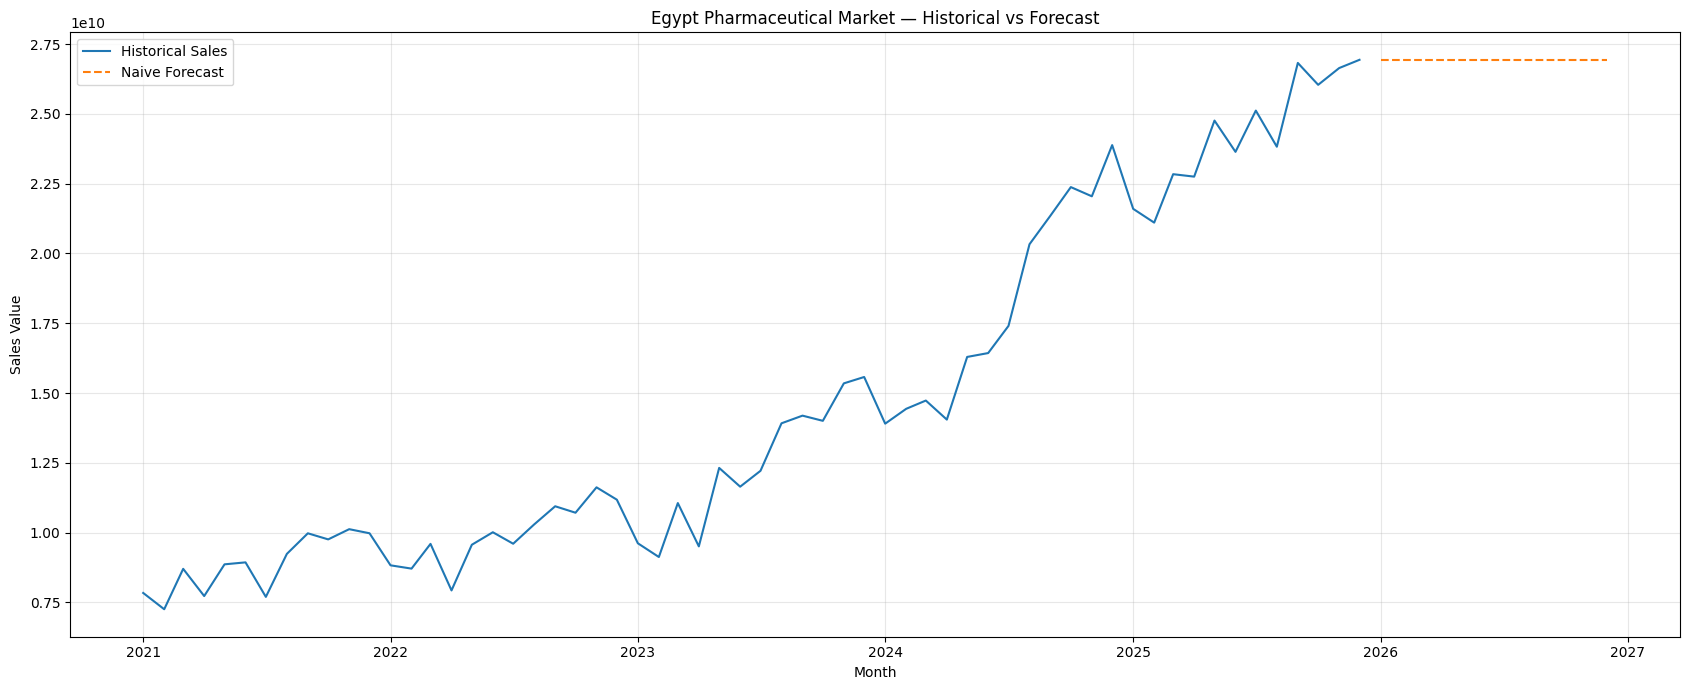

,Month,Forecast_Sales,Previous_Year_Sales,YoY_Growth
0,2026-01-01,2.693493e+10,2.159677e+10,24.717408
1,2026-02-01,2.693493e+10,2.110284e+10,27.636526
2,2026-03-01,2.693493e+10,2.283770e+10,17.940639
3,2026-04-01,2.693493e+10,2.275040e+10,18.393222
4,2026-05-01,2.693493e+10,2.475851e+10,8.790604
5,2026-06-01,2.693493e+10,2.363798e+10,13.947676
6,2026-07-01,2.693493e+10,2.511584e+10,7.242783
7,2026-08-01,2.693493e+10,2.382179e+10,13.068433
8,2026-09-01,2.693493e+10,2.682275e+10,0.418228
9,2026-10-01,2.693493e+10,2.603899e+10,3.440755


,Month,Forecast_Sales,YoY_Growth,Risk
0,2026-01-01,2.693493e+10,24.717408,Normal
1,2026-02-01,2.693493e+10,27.636526,Normal
2,2026-03-01,2.693493e+10,17.940639,Normal
3,2026-04-01,2.693493e+10,18.393222,Normal
4,2026-05-01,2.693493e+10,8.790604,Normal
5,2026-06-01,2.693493e+10,13.947676,Normal
6,2026-07-01,2.693493e+10,7.242783,Normal
7,2026-08-01,2.693493e+10,13.068433,Normal
8,2026-09-01,2.693493e+10,0.418228,Normal
9,2026-10-01,2.693493e+10,3.440755,Normal


,Metric,Value
0,Historical Market Sales,292057810603.731995
1,Forecast Next 12 Months Sales,323219160943.932007
2,Expected Growth,10.669583
3,Best Forecast Model,Naive
4,Model MAPE,6.996617


Forecast outputs exported successfully.


In [17]:
# ============================================================
# 8. MONTHLY GROWTH
# ============================================================

monthly_market["MoM_Growth"] = (
    monthly_market["Sales_Value"]
    .pct_change() * 100
)

monthly_market["YoY_Growth"] = (
    monthly_market["Sales_Value"]
    .pct_change(12) * 100
)

display(
    monthly_market.tail(24)
)


# ============================================================
# 9. ANNUAL MARKET SUMMARY
# ============================================================

annual_market = (
    df.groupby("Year")["Sales Value"]
    .sum()
    .reset_index()
)

annual_market.columns = [
    "Year",
    "Sales_Value"
]

annual_market = (
    annual_market
    .sort_values("Year")
    .reset_index(drop=True)
)

annual_market["YoY_Growth"] = (
    annual_market["Sales_Value"]
    .pct_change() * 100
)

display(annual_market)


# ============================================================
# 10. MARKET CAGR
# ============================================================

start_value = annual_market.iloc[0]["Sales_Value"]
end_value = annual_market.iloc[-1]["Sales_Value"]

number_of_years = (
    annual_market["Year"].max()
    - annual_market["Year"].min()
)

if number_of_years > 0 and start_value > 0:

    market_cagr = (
        (end_value / start_value)
        ** (1 / number_of_years)
        - 1
    ) * 100

else:

    market_cagr = np.nan

print(
    f"Historical Market CAGR: {market_cagr:.2f}%"
)


# ============================================================
# 11. TEMPORAL TRAIN / TEST SPLIT
# ============================================================

forecast_data = monthly_market.copy()

forecast_data = (
    forecast_data
    .sort_values("Month")
    .reset_index(drop=True)
)

split_index = int(
    len(forecast_data) * 0.80
)

train = forecast_data.iloc[:split_index].copy()

test = forecast_data.iloc[split_index:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

print(
    "\nTraining:",
    train["Month"].min(),
    "→",
    train["Month"].max()
)

print(
    "Testing:",
    test["Month"].min(),
    "→",
    test["Month"].max()
)


# ============================================================
# 12. NAIVE FORECAST
# ============================================================

naive_prediction = np.repeat(
    train["Sales_Value"].iloc[-1],
    len(test)
)

naive_mae = mean_absolute_error(
    test["Sales_Value"],
    naive_prediction
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test["Sales_Value"],
        naive_prediction
    )
)

naive_mape = np.mean(
    np.abs(
        (
            test["Sales_Value"]
            - naive_prediction
        )
        / test["Sales_Value"]
    )
) * 100

print("NAIVE MODEL")
print("----------------")
print(f"MAE  : {naive_mae:,.2f}")
print(f"RMSE : {naive_rmse:,.2f}")
print(f"MAPE : {naive_mape:.2f}%")


# ============================================================
# 13. SEASONAL NAIVE
# ============================================================

seasonal_predictions = []

history_values = train["Sales_Value"].tolist()

for i in range(len(test)):

    if len(history_values) >= 12:
        prediction = history_values[-12]
    else:
        prediction = history_values[-1]

    seasonal_predictions.append(prediction)

    history_values.append(
        test["Sales_Value"].iloc[i]
    )

seasonal_predictions = np.array(
    seasonal_predictions
)

seasonal_mae = mean_absolute_error(
    test["Sales_Value"],
    seasonal_predictions
)

seasonal_rmse = np.sqrt(
    mean_squared_error(
        test["Sales_Value"],
        seasonal_predictions
    )
)

seasonal_mape = np.mean(
    np.abs(
        (
            test["Sales_Value"]
            - seasonal_predictions
        )
        / test["Sales_Value"]
    )
) * 100

print("SEASONAL NAIVE")
print("----------------")
print(f"MAE  : {seasonal_mae:,.2f}")
print(f"RMSE : {seasonal_rmse:,.2f}")
print(f"MAPE : {seasonal_mape:.2f}%")


# ============================================================
# 14. EXPONENTIAL SMOOTHING
# ============================================================

ets_model = ExponentialSmoothing(
    train["Sales_Value"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

ets_fit = ets_model.fit(
    optimized=True
)

ets_prediction = ets_fit.forecast(
    len(test)
)

ets_mae = mean_absolute_error(
    test["Sales_Value"],
    ets_prediction
)

ets_rmse = np.sqrt(
    mean_squared_error(
        test["Sales_Value"],
        ets_prediction
    )
)

ets_mape = np.mean(
    np.abs(
        (
            test["Sales_Value"]
            - ets_prediction
        )
        / test["Sales_Value"]
    )
) * 100

print("EXPONENTIAL SMOOTHING")
print("----------------------")
print(f"MAE  : {ets_mae:,.2f}")
print(f"RMSE : {ets_rmse:,.2f}")
print(f"MAPE : {ets_mape:.2f}%")


# ============================================================
# 15. FORECAST MODEL COMPARISON
# ============================================================

plt.figure(figsize=(16, 7))

plt.plot(
    train["Month"],
    train["Sales_Value"],
    label="Train"
)

plt.plot(
    test["Month"],
    test["Sales_Value"],
    label="Actual"
)

plt.plot(
    test["Month"],
    naive_prediction,
    label="Naive"
)

plt.plot(
    test["Month"],
    seasonal_predictions,
    label="Seasonal Naive"
)

plt.plot(
    test["Month"],
    ets_prediction,
    label="Exponential Smoothing"
)

plt.title(
    "Forecast Model Backtesting"
)

plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 16. MODEL PERFORMANCE
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Naive",
        "Seasonal Naive",
        "Exponential Smoothing"
    ],

    "MAE": [
        naive_mae,
        seasonal_mae,
        ets_mae
    ],

    "RMSE": [
        naive_rmse,
        seasonal_rmse,
        ets_rmse
    ],

    "MAPE": [
        naive_mape,
        seasonal_mape,
        ets_mape
    ]
})

model_comparison = (
    model_comparison
    .sort_values("MAPE")
    .reset_index(drop=True)
)

display(model_comparison)


# ============================================================
# 17. LINEAR REGRESSION FORECAST
# ============================================================

lr_data = forecast_data.copy()

lr_data["Trend"] = np.arange(
    len(lr_data)
)

lr_data["Month_Number"] = (
    lr_data["Month"].dt.month
)

lr_data["Quarter"] = (
    lr_data["Month"].dt.quarter
)

lr_train = lr_data.iloc[:split_index].copy()

lr_test = lr_data.iloc[split_index:].copy()

features = [
    "Trend",
    "Month_Number",
    "Quarter"
]

X_train = lr_train[features]
y_train = lr_train["Sales_Value"]

X_test = lr_test[features]
y_test = lr_test["Sales_Value"]

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_prediction = lr_model.predict(
    X_test
)

lr_mae = mean_absolute_error(
    y_test,
    lr_prediction
)

lr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_prediction
    )
)

lr_mape = np.mean(
    np.abs(
        (
            y_test
            - lr_prediction
        )
        / y_test
    )
) * 100

lr_r2 = r2_score(
    y_test,
    lr_prediction
)

print("LINEAR REGRESSION")
print("------------------")
print(f"MAE  : {lr_mae:,.2f}")
print(f"RMSE : {lr_rmse:,.2f}")
print(f"MAPE : {lr_mape:.2f}%")
print(f"R²   : {lr_r2:.4f}")


# ============================================================
# 18. RANDOM FOREST FORECAST
# ============================================================

rf_features = [
    "Trend",
    "Month_Number",
    "Quarter"
]

X_train_rf = lr_train[rf_features].copy()
X_test_rf = lr_test[rf_features].copy()

X_train_rf.columns = (
    X_train_rf.columns.astype(str)
)

X_test_rf.columns = (
    X_test_rf.columns.astype(str)
)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train
)

rf_prediction = rf_model.predict(
    X_test_rf
)

rf_mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

rf_mape = np.mean(
    np.abs(
        (
            y_test
            - rf_prediction
        )
        / y_test
    )
) * 100

rf_r2 = r2_score(
    y_test,
    rf_prediction
)

print("RANDOM FOREST")
print("----------------")
print(f"MAE  : {rf_mae:,.2f}")
print(f"RMSE : {rf_rmse:,.2f}")
print(f"MAPE : {rf_mape:.2f}%")
print(f"R²   : {rf_r2:.4f}")


# ============================================================
# 19. GRADIENT BOOSTING
# ============================================================

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train_rf,
    y_train
)

gb_prediction = gb_model.predict(
    X_test_rf
)

gb_mae = mean_absolute_error(
    y_test,
    gb_prediction
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_prediction
    )
)

gb_mape = np.mean(
    np.abs(
        (
            y_test
            - gb_prediction
        )
        / y_test
    )
) * 100

gb_r2 = r2_score(
    y_test,
    gb_prediction
)

print("GRADIENT BOOSTING")
print("------------------")
print(f"MAE  : {gb_mae:,.2f}")
print(f"RMSE : {gb_rmse:,.2f}")
print(f"MAPE : {gb_mape:.2f}%")
print(f"R²   : {gb_r2:.4f}")


# ============================================================
# 20. FINAL MODEL COMPARISON
# ============================================================

all_models = pd.DataFrame({

    "Model": [
        "Naive",
        "Seasonal Naive",
        "Exponential Smoothing",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        naive_mae,
        seasonal_mae,
        ets_mae,
        lr_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        naive_rmse,
        seasonal_rmse,
        ets_rmse,
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],

    "MAPE": [
        naive_mape,
        seasonal_mape,
        ets_mape,
        lr_mape,
        rf_mape,
        gb_mape
    ],

    "R2": [
        np.nan,
        np.nan,
        np.nan,
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

all_models = (
    all_models
    .sort_values("MAPE")
    .reset_index(drop=True)
)

display(all_models)


# ============================================================
# 21. BEST MODEL
# ============================================================

best_model_name = (
    all_models.iloc[0]["Model"]
)

best_model_mape = (
    all_models.iloc[0]["MAPE"]
)

print("BEST MODEL")
print("-----------")
print("Model:", best_model_name)
print(f"MAPE: {best_model_mape:.2f}%")


# ============================================================
# 22. PREPARE FULL DATA FOR FINAL FORECAST
# ============================================================

full_market = monthly_market.copy()

full_market = (
    full_market
    .sort_values("Month")
    .reset_index(drop=True)
)

full_market["Trend"] = np.arange(
    len(full_market)
)

full_market["Month_Number"] = (
    full_market["Month"].dt.month
)

full_market["Quarter"] = (
    full_market["Month"].dt.quarter
)


# ============================================================
# 23. FUTURE 12 MONTHS
# ============================================================

future_dates = pd.date_range(
    start=(
        full_market["Month"].max()
        + pd.offsets.MonthBegin(1)
    ),
    periods=12,
    freq="MS"
)

future_features = pd.DataFrame({

    "Month": future_dates,

    "Trend": np.arange(
        len(full_market),
        len(full_market) + 12
    ),

    "Month_Number": future_dates.month,

    "Quarter": future_dates.quarter
})

future_X = future_features[
    [
        "Trend",
        "Month_Number",
        "Quarter"
    ]
].copy()

future_X.columns = (
    future_X.columns.astype(str)
)


# ============================================================
# 24. REFIT BEST MODEL ON FULL HISTORY
# ============================================================

if best_model_name == "Linear Regression":

    final_model = LinearRegression()

    final_model.fit(
        full_market[rf_features],
        full_market["Sales_Value"]
    )

    final_forecast_values = (
        final_model.predict(future_X)
    )


elif best_model_name == "Random Forest":

    final_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    final_model.fit(
        full_market[rf_features],
        full_market["Sales_Value"]
    )

    final_forecast_values = (
        final_model.predict(future_X)
    )


elif best_model_name == "Gradient Boosting":

    final_model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        random_state=42
    )

    final_model.fit(
        full_market[rf_features],
        full_market["Sales_Value"]
    )

    final_forecast_values = (
        final_model.predict(future_X)
    )


elif best_model_name == "Exponential Smoothing":

    final_model = ExponentialSmoothing(
        full_market["Sales_Value"],
        trend="add",
        seasonal="add",
        seasonal_periods=12
    ).fit(
        optimized=True
    )

    final_forecast_values = (
        final_model
        .forecast(12)
        .values
    )


elif best_model_name == "Seasonal Naive":

    history_values = (
        full_market["Sales_Value"]
        .tolist()
    )

    final_forecast_values = []

    for i in range(12):

        prediction = (
            history_values[-12]
        )

        final_forecast_values.append(
            prediction
        )

        history_values.append(
            prediction
        )

    final_forecast_values = np.array(
        final_forecast_values
    )


elif best_model_name == "Naive":

    final_forecast_values = np.repeat(
        full_market["Sales_Value"].iloc[-1],
        12
    )


# ============================================================
# 25. FINAL MARKET FORECAST
# ============================================================

forecast_2026 = pd.DataFrame({

    "Month": future_dates,

    "Forecast_Sales":
        final_forecast_values
})

display(forecast_2026)


# ============================================================
# 26. TOTAL FORECAST & MARKET GROWTH
# ============================================================

total_forecast_2026 = (
    forecast_2026["Forecast_Sales"]
    .sum()
)

last_12_months_sales = (
    full_market
    .tail(12)["Sales_Value"]
    .sum()
)

expected_market_growth = (
    (
        total_forecast_2026
        / last_12_months_sales
    ) - 1
) * 100

print(
    f"Last 12 Months Sales : "
    f"{last_12_months_sales:,.0f}"
)

print(
    f"Forecast Next 12M Sales : "
    f"{total_forecast_2026:,.0f}"
)

print(
    f"Expected Growth      : "
    f"{expected_market_growth:.2f}%"
)


# ============================================================
# 27. HISTORICAL VS FORECAST
# ============================================================

plt.figure(figsize=(17, 7))

plt.plot(
    full_market["Month"],
    full_market["Sales_Value"],
    label="Historical Sales"
)

plt.plot(
    forecast_2026["Month"],
    forecast_2026["Forecast_Sales"],
    linestyle="--",
    label=f"{best_model_name} Forecast"
)

plt.title(
    "Egypt Pharmaceutical Market — Historical vs Forecast"
)

plt.xlabel("Month")
plt.ylabel("Sales Value")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 28. FORECAST GROWTH
# ============================================================

# Compare each forecast month with the
# corresponding month in the previous 12 months.

previous_year_values = (
    full_market
    .tail(12)["Sales_Value"]
    .values
)

forecast_2026["Previous_Year_Sales"] = (
    previous_year_values
)

forecast_2026["YoY_Growth"] = (
    (
        forecast_2026["Forecast_Sales"]
        /
        forecast_2026["Previous_Year_Sales"]
    ) - 1
) * 100

display(forecast_2026)


# ============================================================
# 29. FORECAST RISK SIGNAL
# ============================================================

forecast_2026["Risk"] = "Normal"

forecast_2026.loc[
    forecast_2026["YoY_Growth"] < -10,
    "Risk"
] = "High Downside Risk"

forecast_2026.loc[
    forecast_2026["YoY_Growth"] > 30,
    "Risk"
] = "High Growth / Volatility"

display(
    forecast_2026[
        [
            "Month",
            "Forecast_Sales",
            "YoY_Growth",
            "Risk"
        ]
    ]
)


# ============================================================
# 30. FORECAST EXECUTIVE SUMMARY
# ============================================================

forecast_summary = pd.DataFrame({

    "Metric": [
        "Historical Market Sales",
        "Forecast Next 12 Months Sales",
        "Expected Growth",
        "Best Forecast Model",
        "Model MAPE"
    ],

    "Value": [

        last_12_months_sales,

        total_forecast_2026,

        expected_market_growth,

        best_model_name,

        best_model_mape
    ]
})

display(forecast_summary)


# ============================================================
# 31. EXPORT FORECAST RESULTS
# ============================================================

forecast_2026.to_csv(
    "market_forecast_2026.csv",
    index=False
)

all_models.to_csv(
    "forecast_model_comparison.csv",
    index=False
)

forecast_summary.to_csv(
    "forecast_executive_summary.csv",
    index=False
)

print(
    "Forecast outputs exported successfully."
)